In [1]:
!pip install sentence-transformers faiss-cpu -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 74.9 MB/s eta 0:00:00:00:0100:01


In [2]:
import pandas as pd
import numpy as np
import pickle, os
import faiss
from sentence_transformers import SentenceTransformer
from tqdm.notebook import tqdm

df = pd.read_csv('/kaggle/input/datasets/b22dckh131hongkhnhvn/arxiv-preprocessed/arxiv_preprocessed.csv')
df = df.dropna(subset=['text_semantic']).reset_index(drop=True)
print(f"Số paper: {len(df):,}")

Số paper: 100,000


## Vai trò của notebook

Notebook này đảm nhiệm phần **semantic retrieval**:

- Dùng **SPECTER** để biến title + abstract thành vector ngữ nghĩa.
- Dùng **FAISS** để tìm kiếm nearest neighbors nhanh trên 100,000 paper.
- Phù hợp với query tự nhiên, query có từ đồng nghĩa, hoặc mô tả ý tưởng thay vì từ khóa chính xác.

Phần bổ sung bên dưới sửa lỗi title matching và thêm đánh giá định lượng cho semantic retrieval.


In [3]:
# So sánh 3 model phổ biến để nhóm tự chọn:
#
# Model                        Size    Speed   Accuracy   Phù hợp
# ─────────────────────────────────────────────────────────────────
# all-MiniLM-L6-v2             80MB    Nhanh   Tốt        Laptop/Colab
# all-mpnet-base-v2            420MB   TB      Rất tốt    Colab/Kaggle
# allenai-specter              420MB   TB      Xuất sắc   ArXiv (chuyên biệt!)
#
# → Khuyên dùng allenai-specter vì được train riêng cho paper khoa học!

MODEL_NAME = 'allenai-specter'
print(f"Loading model: {MODEL_NAME}...")
model = SentenceTransformer(MODEL_NAME)
print("Done!")

Loading model: allenai-specter...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Done!


In [4]:
# SPECTER encode theo format: title + [SEP] + abstract
# (đây là format chuẩn của model này)
corpus = (df['title'] + ' [SEP] ' + df['abstract']).fillna('').tolist()

print(f"Đang encode {len(corpus):,} papers...")
print("(Với Kaggle GPU P100, 100k papers mất ~30-40 phút)")

embeddings = model.encode(
    corpus,
    batch_size      = 128,       # tăng batch nếu có GPU
    show_progress_bar = True,
    convert_to_numpy  = True,
    normalize_embeddings = True, # normalize sẵn → cosine = dot product
)

print(f"\nEmbedding shape: {embeddings.shape}")
# → (100000, 768)  — mỗi paper là 1 vector 768 chiều

# Lưu lại ngay — tránh mất khi Kaggle timeout
np.save('/kaggle/working/embeddings.npy', embeddings)
print("Đã lưu embeddings.npy!")

Đang encode 100,000 papers...
(Với Kaggle GPU P100, 100k papers mất ~30-40 phút)


Batches:   0%|          | 0/782 [00:00<?, ?it/s]


Embedding shape: (100000, 768)
Đã lưu embeddings.npy!


In [5]:
# Load lại nếu cần
# embeddings = np.load('/kaggle/input/.../embeddings.npy')

dim = embeddings.shape[1]   # 768

# ── Lựa chọn loại FAISS Index ───────────────────────────────
#
# IndexFlatIP   — tìm chính xác 100%, chậm hơn với dataset lớn
# IndexIVFFlat  — tìm gần đúng, nhanh hơn ~10x, mất ~1% accuracy
#
# Với 50k papers → dùng IndexFlatIP là đủ nhanh và chính xác

index_flat = faiss.IndexFlatIP(dim)     # IP = Inner Product (cosine nếu đã normalize)
index_flat.add(embeddings.astype('float32'))
print(f"FAISS IndexFlatIP: {index_flat.ntotal:,} vectors")

# ── Index nhanh hơn cho dataset lớn (tùy chọn) ───────────────
nlist       = 100    # số cluster
quantizer   = faiss.IndexFlatIP(dim)
index_ivf   = faiss.IndexIVFFlat(quantizer, dim, nlist, faiss.METRIC_INNER_PRODUCT)
index_ivf.train(embeddings.astype('float32'))
index_ivf.add(embeddings.astype('float32'))
index_ivf.nprobe = 10    # số cluster tìm kiếm — tăng → chính xác hơn nhưng chậm hơn
print(f"FAISS IndexIVFFlat: {index_ivf.ntotal:,} vectors")

# Lưu cả 2 index
faiss.write_index(index_flat, '/kaggle/working/faiss_flat.index')
faiss.write_index(index_ivf,  '/kaggle/working/faiss_ivf.index')
print("Đã lưu FAISS index!")

FAISS IndexFlatIP: 100,000 vectors
FAISS IndexIVFFlat: 100,000 vectors
Đã lưu FAISS index!


In [6]:
def preprocess_query_semantic(query: str) -> str:
    """Query cho SBERT — giữ nguyên câu, chỉ clean LaTeX"""
    import re
    query = re.sub(r'\$.*?\$', ' ', query)
    query = re.sub(r'\s+', ' ', query).strip()
    return query

def search_semantic(query: str, top_k: int = 10,
                    use_ivf: bool = False) -> pd.DataFrame:
    """Tìm kiếm theo ngữ nghĩa bằng SBERT + FAISS"""
    # Encode query thành vector
    q_clean = preprocess_query_semantic(query)
    q_emb   = model.encode(
        [q_clean],
        normalize_embeddings = True,
        convert_to_numpy     = True,
    ).astype('float32')

    # Tìm top-k nearest neighbors
    index = index_ivf if use_ivf else index_flat
    scores, indices = index.search(q_emb, top_k)

    results = df.iloc[indices[0]][['id','title','abstract',
                                   'categories','year']].copy()
    results['score']  = scores[0].round(4)
    results['method'] = 'Semantic-SPECTER'
    return results.reset_index(drop=True)

def search_semantic_verbose(query: str, top_k: int = 5):
    """In kết quả đẹp kèm snippet abstract"""
    results = search_semantic(query, top_k)
    print(f"\n{'='*65}")
    print(f"  Query: \"{query}\"")
    print(f"{'='*65}")
    for i, row in results.iterrows():
        print(f"\n  {i+1}. [{row['score']:.4f}] {row['title'][:65]}")
        print(f"       Categories: {row['categories']}  ({row['year']})")
        print(f"       Abstract:   {row['abstract'][:120]}...")
    return results

In [7]:
# Load lại TF-IDF của TV1 để so sánh
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf_vec = pickle.load(open('/kaggle/input/datasets/b22dckh131hongkhnhvn/tv1-models/tfidf_vectorizer.pkl','rb'))
tfidf_mat = pickle.load(open('/kaggle/input/datasets/b22dckh131hongkhnhvn/tv1-models/tfidf_matrix.pkl','rb'))

import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import nltk; nltk.download('stopwords', quiet=True)

STOP  = set(stopwords.words('english'))
PS    = PorterStemmer()

def search_tfidf_quick(query, top_k=5):
    q = ' '.join([PS.stem(t) for t in re.sub(r'[^a-z\s]','',
                  query.lower()).split() if t not in STOP])
    qv = tfidf_vec.transform([q])
    sc = cosine_similarity(qv, tfidf_mat).flatten()
    idx = sc.argsort()[::-1][:top_k]
    r = df.iloc[idx][['title','year']].copy()
    r['score'] = sc[idx].round(4)
    return r

def compare_methods(query: str, top_k: int = 5):
    print(f"\n{'='*65}")
    print(f"  Query: \"{query}\"")
    print('='*65)

    r_sem   = search_semantic(query, top_k)
    r_tfidf = search_tfidf_quick(query, top_k)

    print(f"\n  [SEMANTIC — SPECTER]")
    print(f"  {'Score':<8} {'Year':<6} Title")
    print(f"  {'─'*55}")
    for _, row in r_sem.iterrows():
        print(f"  {row['score']:<8.4f} {row['year']:<6} {row['title'][:50]}")

    print(f"\n  [TF-IDF — Keyword]")
    print(f"  {'Score':<8} {'Year':<6} Title")
    print(f"  {'─'*55}")
    for _, row in r_tfidf.iterrows():
        print(f"  {row['score']:<8.4f} {row['year']:<6} {row['title'][:50]}")

# ── Test với các query kiểu khác nhau ───────────────────────

# Query 1: Từ khóa kỹ thuật — 2 method sẽ ra kết quả tương tự
compare_methods("transformer self-attention mechanism")

# Query 2: Query dạng câu hỏi — semantic sẽ tốt hơn rõ ràng
compare_methods("how do machines understand human language")

# Query 3: Synonym / diễn đạt khác — semantic xử lý tốt hơn
compare_methods("predicting future stock prices using AI")

# Query 4: Query mô tả ý tưởng — TF-IDF sẽ thất bại
compare_methods("model that reads image and generates description text")


  Query: "transformer self-attention mechanism"

  [SEMANTIC — SPECTER]
  Score    Year   Title
  ───────────────────────────────────────────────────────
  0.9027   2021   An Attentive Survey of Attention Models
  0.8877   2020   Attention that does not Explain Away
  0.8822   2018   Troy: Give Attention to Saliency and for Saliency
  0.8804   2020   Exploring Self-attention for Image Recognition
  0.8796   2020   A Mathematical Theory of Attention

  [TF-IDF — Keyword]
  Score    Year   Title
  ───────────────────────────────────────────────────────
  0.2227   2020   Higher Order Linear Transformer
  0.1899   2020   Difference-in-Differences: Bridging Normalization 
  0.1783   2020   Linformer: Self-Attention with Linear Complexity
  0.1747   2020   Dialogue Transformers
  0.1719   2018   Learning Independent Causal Mechanisms

  Query: "how do machines understand human language"

  [SEMANTIC — SPECTER]
  Score    Year   Title
  ───────────────────────────────────────────────────────

In [8]:
def find_paper_idx_by_title(keyword: str):
    """Tìm paper theo title, tránh match sai kiểu 'BERT' nằm trong 'Hilbert'."""
    keyword = keyword.lower().strip()
    titles = df['title'].fillna('').str.lower().str.strip()

    exact = df.index[titles == keyword]
    if len(exact) > 0:
        return exact[0]

    # Nếu query là một token ngắn như BERT, bắt buộc match theo word boundary
    # trước khi dùng contains để tránh match nhầm Hilbert.
    import re
    if len(keyword.split()) == 1:
        pattern = r'\b' + re.escape(keyword) + r'\b'
        word_match = df.index[titles.str.contains(pattern, regex=True)]
        if len(word_match) > 0:
            return word_match[0]
    else:
        # Với query nhiều từ, ưu tiên match theo cụm từ nguyên văn.
        phrase = df.index[titles.str.contains(keyword, regex=False)]
        if len(phrase) > 0:
            return phrase[0]

    return None


def paper_similarity(title_a: str, title_b: str) -> float:
    """Tính cosine similarity giữa 2 paper theo title."""
    idx_a = find_paper_idx_by_title(title_a)
    idx_b = find_paper_idx_by_title(title_b)

    if idx_a is None or idx_b is None:
        print("Không tìm thấy paper!")
        return np.nan

    emb_a = embeddings[idx_a]
    emb_b = embeddings[idx_b]
    sim = float(np.dot(emb_a, emb_b))   # đã normalize → dot = cosine

    label = 'rất giống' if sim > 0.85 else 'liên quan' if sim > 0.7 else 'ít liên quan'
    print(f"\nPaper A: {df.loc[idx_a, 'title'][:60]}")
    print(f"Paper B: {df.loc[idx_b, 'title'][:60]}")
    print(f"Cosine Similarity: {sim:.4f}  ({label})")
    return sim


# Test
paper_similarity("BERT", "Attention Is All You Need")
paper_similarity("image classification", "object detection")
paper_similarity("neural machine translation", "protein folding")



Paper A: BERT: Pre-training of Deep Bidirectional Transformers for La
Paper B: Attention Is All You Need
Cosine Similarity: 0.8804  (rất giống)

Paper A: Towards Effective Codebookless Model for Image Classificatio
Paper B: Salient Object Detection: A Survey
Cosine Similarity: 0.8354  (liên quan)

Paper A: Beam Search Strategies for Neural Machine Translation
Paper B: Protein Folding Optimization using Differential Evolution Ex
Cosine Similarity: 0.6839  (ít liên quan)


0.6839358806610107

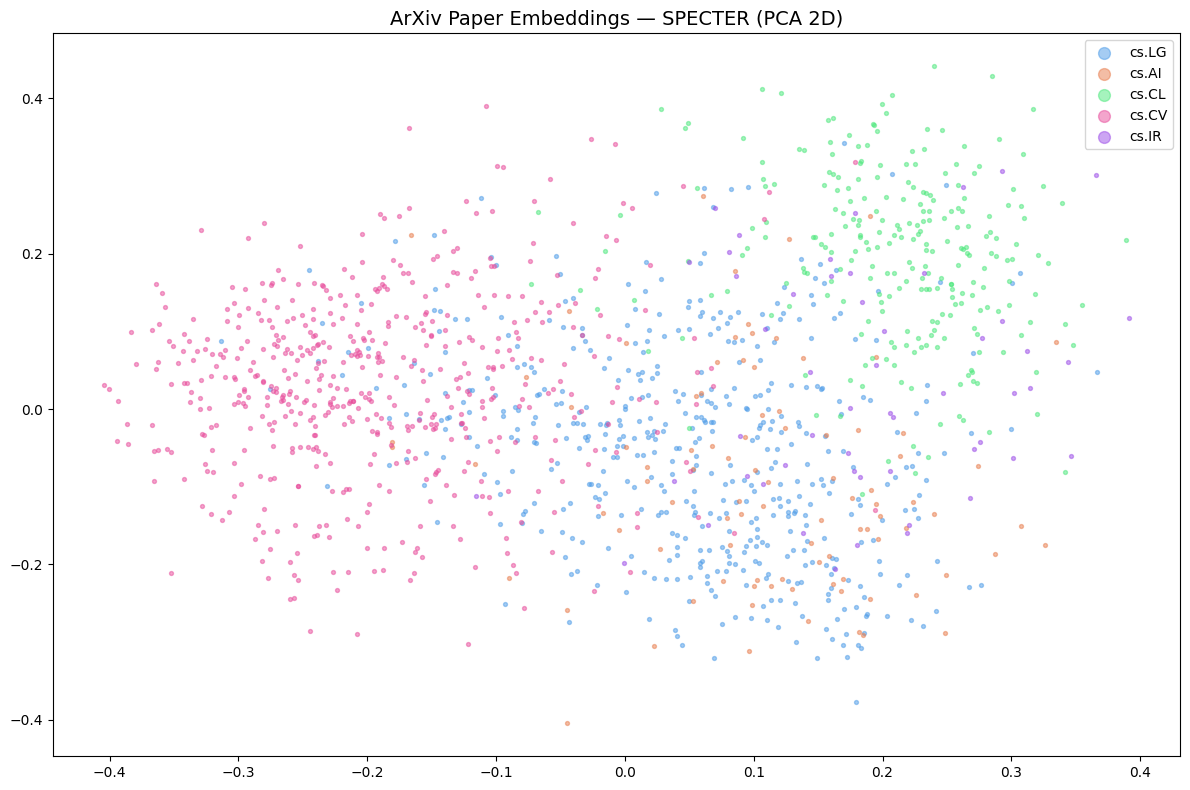

Saved!


In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Lấy 2000 paper ngẫu nhiên để visualize
sample_idx  = np.random.choice(len(df), 2000, replace=False)
sample_embs = embeddings[sample_idx]
sample_cats = df.iloc[sample_idx]['categories'].str.split().str[0]

# Giảm chiều từ 768 → 2D bằng PCA
pca  = PCA(n_components=2, random_state=42)
emb_2d = pca.fit_transform(sample_embs)

# Vẽ
cat_colors = {
    'cs.LG':'#4C9BE8', 'cs.AI':'#E87C4C', 'cs.CL':'#4CE87C',
    'cs.CV':'#E84C9B', 'cs.IR':'#9B4CE8'
}
plt.figure(figsize=(12, 8))
for cat, color in cat_colors.items():
    mask = sample_cats == cat
    plt.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                c=color, label=cat, alpha=0.5, s=8)

plt.title('ArXiv Paper Embeddings — SPECTER (PCA 2D)', fontsize=14)
plt.legend(markerscale=3)
plt.tight_layout()
plt.savefig('/kaggle/working/embedding_visualization.png', dpi=150)
plt.show()
print("Saved!")

In [10]:
os.makedirs('/kaggle/working/models_tv2', exist_ok=True)

# embeddings và FAISS index đã lưu ở bước trên
# Lưu thêm config để load lại dễ dàng
config = {
    'model_name': MODEL_NAME,
    'embedding_dim': dim,
    'num_papers': len(df),
    'index_type': 'FlatIP + IVFFlat',
}
pickle.dump(config, open('/kaggle/working/models_tv2/config.pkl', 'wb'))

print("TV2 hoàn tất! Files cần giữ lại:")
print("  embeddings.npy         — vector của 100k papers")
print("  faiss_flat.index       — index tìm kiếm chính xác")
print("  faiss_ivf.index        — index tìm kiếm nhanh")
print("  config.pkl             — thông tin model")

TV2 hoàn tất! Files cần giữ lại:
  embeddings.npy         — vector của 100k papers
  faiss_flat.index       — index tìm kiếm chính xác
  faiss_ivf.index        — index tìm kiếm nhanh
  config.pkl             — thông tin model


## Đánh giá bổ sung

Đánh giá semantic retrieval bằng cách lấy một paper làm query, tìm các paper gần nhất trong FAISS, loại bỏ chính nó, rồi tính Precision@K/NDCG@K theo category overlap. Cách này giúp so sánh với các notebook keyword/D2D bằng cùng tiêu chí.


In [11]:
from math import log2


cat_sets = df['categories'].fillna('').apply(lambda x: set(str(x).split())).to_list()


def search_semantic_by_index(idx: int, top_k: int = 10, use_ivf: bool = False) -> pd.DataFrame:
    q_emb = embeddings[idx:idx + 1].astype('float32')
    index = index_ivf if use_ivf else index_flat
    scores, indices = index.search(q_emb, top_k + 1)

    rows = []
    row_indices = []
    for score, paper_idx in zip(scores[0], indices[0]):
        if paper_idx == idx:
            continue
        row = df.iloc[paper_idx][['id', 'title', 'categories', 'year']].copy()
        row['score'] = round(float(score), 4)
        row['method'] = 'Semantic-SPECTER'
        rows.append(row)
        row_indices.append(paper_idx)
        if len(rows) == top_k:
            break

    result = pd.DataFrame(rows)
    result.index = row_indices
    return result


def _precision_at_k(results: pd.DataFrame, query_cats: set, k: int) -> float:
    hits = sum(
        len(query_cats & cat_sets[row_idx]) > 0
        for row_idx in results.head(k).index
    )
    return hits / k


def _ndcg_at_k(results: pd.DataFrame, query_cats: set, k: int) -> float:
    rels = [
        1 if len(query_cats & cat_sets[row_idx]) > 0 else 0
        for row_idx in results.head(k).index
    ]
    dcg = sum(rel / log2(rank + 2) for rank, rel in enumerate(rels))
    idcg = sum(1 / log2(rank + 2) for rank in range(k))
    return dcg / idcg if idcg > 0 else 0.0


def evaluate_semantic_retrieval(test_size: int = 100, k_values=(5, 10), random_state: int = 42):
    rng = np.random.default_rng(random_state)
    sample_idx = rng.choice(len(df), size=min(test_size, len(df)), replace=False)
    records = []

    for idx in tqdm(sample_idx, desc='Evaluating semantic retrieval'):
        query_cats = cat_sets[idx]
        results = search_semantic_by_index(idx, top_k=max(k_values))

        for k in k_values:
            records.append({
                'method': 'Semantic-SPECTER',
                'k': k,
                'P@K': _precision_at_k(results, query_cats, k),
                'NDCG@K': _ndcg_at_k(results, query_cats, k),
            })

    eval_df = pd.DataFrame(records)
    summary = eval_df.groupby(['method', 'k'])[['P@K', 'NDCG@K']].mean().round(4)
    print(summary)
    return eval_df, summary


# Chạy khi cần báo cáo định lượng:
semantic_eval_df, semantic_summary = evaluate_semantic_retrieval(test_size=100, k_values=(5, 10))


Evaluating semantic retrieval:   0%|          | 0/100 [00:00<?, ?it/s]

                       P@K  NDCG@K
method           k                
Semantic-SPECTER 5   0.936  0.9342
                 10  0.926  0.9275


## Nhận xét để đưa vào báo cáo

Semantic retrieval là phần cải tiến so với keyword retrieval vì mô hình có thể bắt quan hệ ngữ nghĩa giữa title/abstract và query. Hướng này phù hợp nhất khi người dùng nhập câu tự nhiên hoặc diễn đạt khác từ khóa trong paper. Hạn chế chính là chi phí encode ban đầu cao, phụ thuộc GPU và cần lưu embedding/index để tái sử dụng.
